# Notebook 01 — Data Exploration

Load, inspect, and visualise all three datasets.
Highlight the injected anomalies in Dataset 3 (Retail).

In [1]:
import json
import logging
import warnings
from pathlib import Path

logging.getLogger("prophet").setLevel(logging.WARNING)
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100})

FIGURES_DIR = Path("outputs/figures")
RESULTS_DIR = Path("outputs/results")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def save_fig(fig: plt.Figure, name: str) -> None:
    path = FIGURES_DIR / name
    fig.savefig(path, bbox_inches="tight", dpi=120)
    print(f"Saved figure → {path}")


def save_json(data, name: str) -> None:
    path = RESULTS_DIR / name
    if isinstance(data, pd.DataFrame):
        payload = data.to_dict(orient="records")
    else:
        payload = data
    path.write_text(json.dumps(payload, indent=2, default=str))
    print(f"Saved results → {path}")


print("Ready.")


Ready.


In [2]:
from src.datasets.loader import load_airline, load_electricity, load_retail_base
from src.datasets.injector import inject_anomalies, ANOMALY_EVENTS

airline     = load_airline()
electricity = load_electricity()
retail_base = load_retail_base()
retail      = inject_anomalies(retail_base)

for name, s in [("Airline", airline), ("Electricity", electricity), ("Retail", retail)]:
    print(f"{name:15s}  {len(s):4d} pts  "
          f"{s.index[0].date()} → {s.index[-1].date()}  mean={s.mean():.1f}")


Airline           144 pts  1949-01-01 → 1960-12-01  mean=280.3
Electricity       397 pts  1990-01-01 → 2023-01-01  mean=132.1
Retail            208 pts  2020-01-06 → 2023-12-25  mean=545.6


## All three series

Saved figure → outputs/figures/01_all_datasets.png


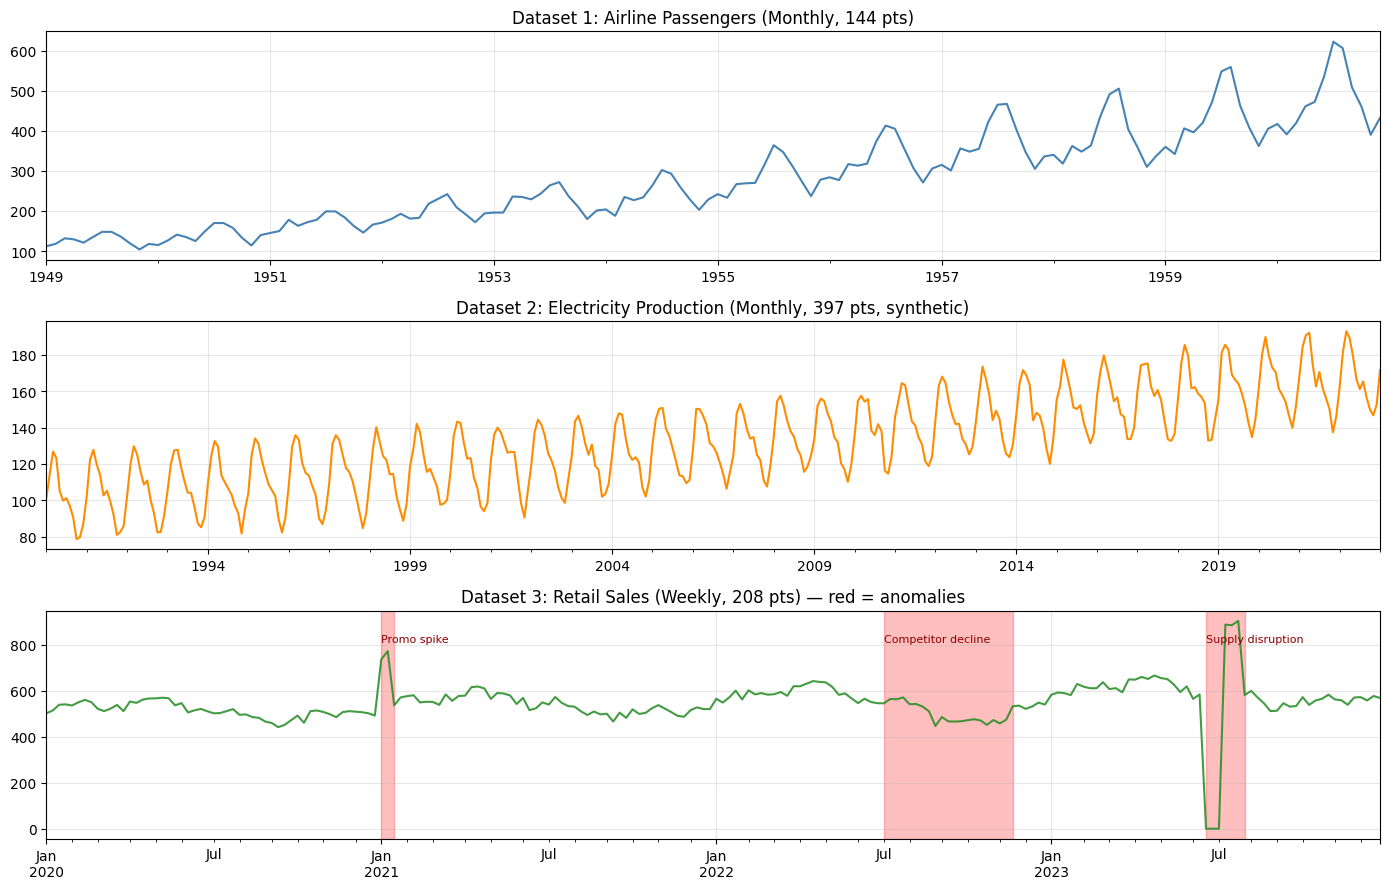

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9))

airline.plot(ax=axes[0], color="steelblue")
axes[0].set_title("Dataset 1: Airline Passengers (Monthly, 144 pts)")

electricity.plot(ax=axes[1], color="darkorange")
axes[1].set_title("Dataset 2: Electricity Production (Monthly, 397 pts, synthetic)")

retail.plot(ax=axes[2], color="forestgreen", alpha=0.85)
axes[2].set_title("Dataset 3: Retail Sales (Weekly, 208 pts) — red = anomalies")
for ev in ANOMALY_EVENTS:
    s_i, e_i = int(ev["start"]), int(ev["end"])
    axes[2].axvspan(retail.index[s_i], retail.index[e_i], alpha=0.25, color="red")
    axes[2].annotate(str(ev["label"]), xy=(retail.index[s_i], retail.max() * 0.9),
                     fontsize=8, color="darkred")

for ax in axes:
    ax.grid(alpha=0.3)

plt.tight_layout()
save_fig(fig, "01_all_datasets.png")
plt.show()


## ACF and PACF — Airline Passengers

A spike at lag 12 confirms annual seasonality.

Saved figure → outputs/figures/01_acf_pacf.png


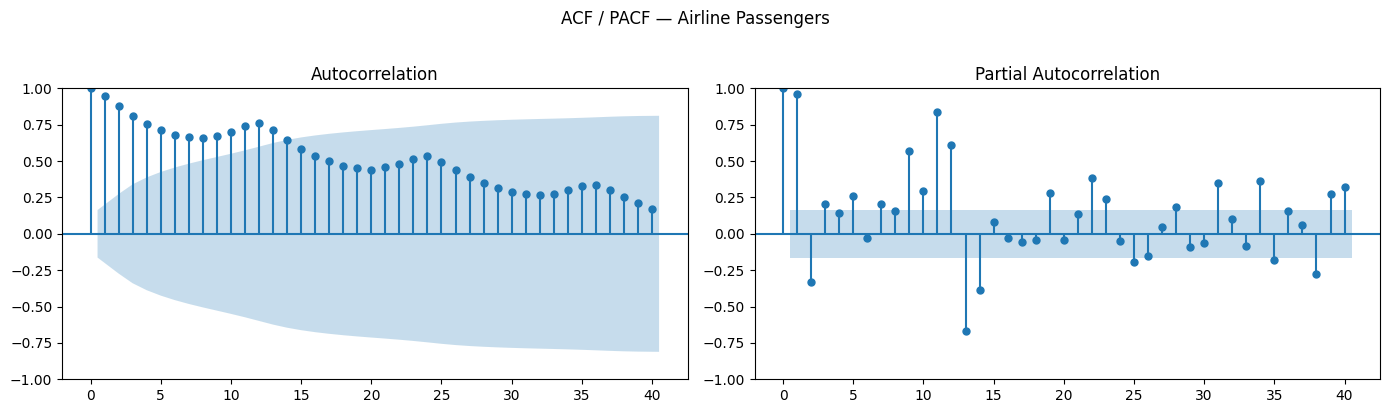

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(airline, lags=40, ax=axes[0])
plot_pacf(airline, lags=40, ax=axes[1], method="ols")
plt.suptitle("ACF / PACF — Airline Passengers", y=1.02)
plt.tight_layout()
save_fig(fig, "01_acf_pacf.png")
plt.show()


## Seasonal decomposition

Saved figure → outputs/figures/01_decomp_airline.png


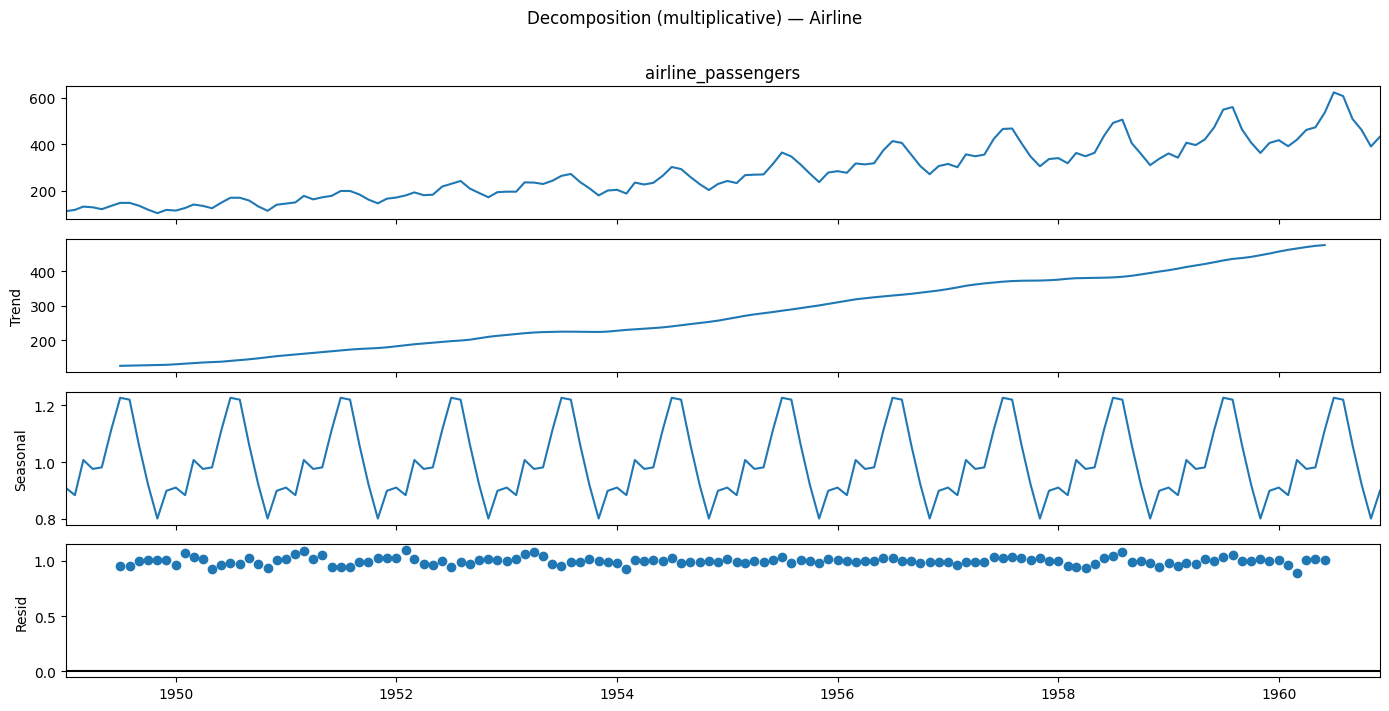

Saved figure → outputs/figures/01_decomp_electricity.png


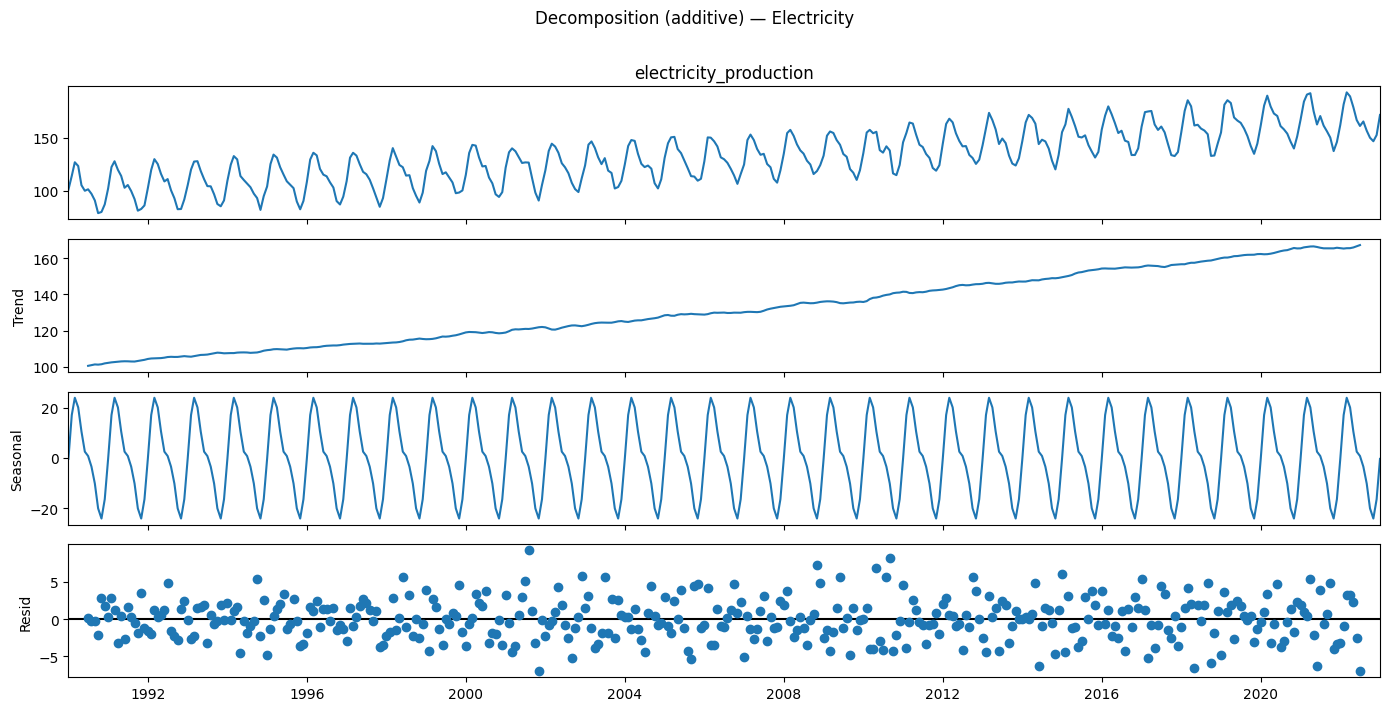

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose

for series, name, model, period in [
    (airline,     "Airline",     "multiplicative", 12),
    (electricity, "Electricity", "additive",       12),
]:
    decomp = seasonal_decompose(series, model=model, period=period)
    fig = decomp.plot()
    fig.set_size_inches(14, 7)
    fig.suptitle(f"Decomposition ({model}) — {name}", y=1.01)
    plt.tight_layout()
    save_fig(fig, f"01_decomp_{name.lower()}.png")
    plt.show()


## Retail: base vs anomaly-injected

Saved figure → outputs/figures/01_retail_anomalies.png


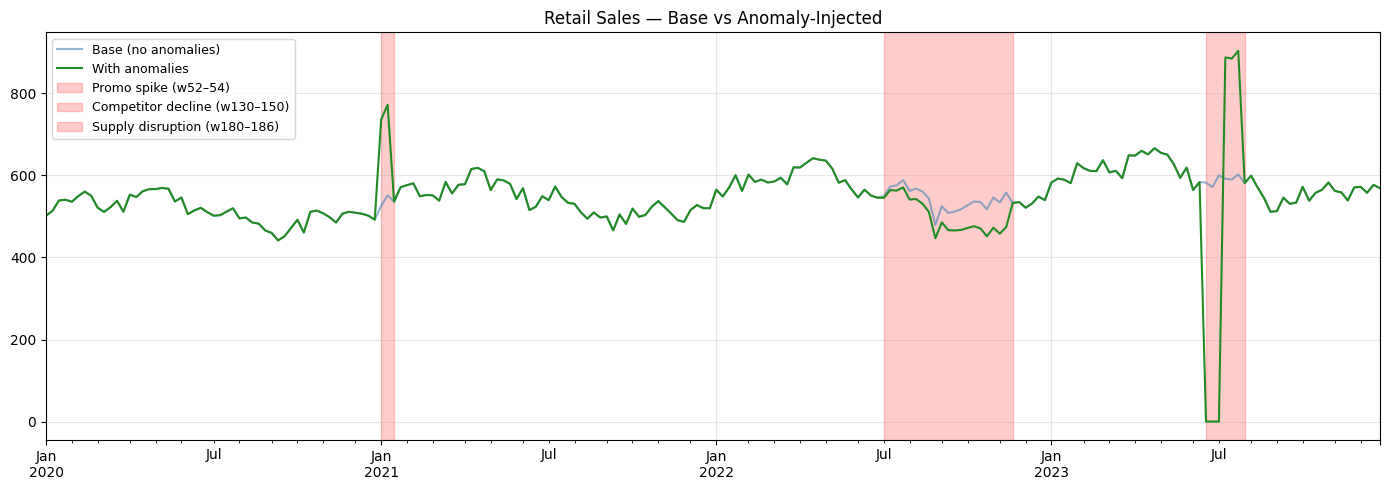

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
retail_base.plot(ax=ax, label="Base (no anomalies)", color="steelblue", alpha=0.6)
retail.plot(ax=ax, label="With anomalies", color="forestgreen")

for ev in ANOMALY_EVENTS:
    s_i, e_i = int(ev["start"]), int(ev["end"])
    ax.axvspan(retail.index[s_i], retail.index[e_i], alpha=0.2, color="red",
               label=f'{ev["label"]} (w{s_i}–{e_i})')

ax.set_title("Retail Sales — Base vs Anomaly-Injected")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, "01_retail_anomalies.png")
plt.show()


## Summary statistics

In [7]:
stats = pd.DataFrame({
    "Dataset":  ["Airline", "Electricity", "Retail (base)", "Retail (anomalies)"],
    "Points":   [len(airline), len(electricity), len(retail_base), len(retail)],
    "Freq":     ["Monthly"] * 2 + ["Weekly"] * 2,
    "Mean":     [s.mean() for s in [airline, electricity, retail_base, retail]],
    "Std":      [s.std()  for s in [airline, electricity, retail_base, retail]],
    "CV (%)":   [s.std() / s.mean() * 100 for s in [airline, electricity, retail_base, retail]],
}).set_index("Dataset").round(2)
save_json(stats.reset_index(), "01_summary_stats.json")
stats


Saved results → outputs/results/01_summary_stats.json


,Points,Freq,Mean,Std,CV (%)
Dataset,,,,,
Airline,144,Monthly,280.30,119.97,42.80
Electricity,397,Monthly,132.12,25.12,19.01
Retail (base),208,Weekly,551.76,44.92,8.14
Retail (anomalies),208,Weekly,545.64,93.70,17.17


## Key takeaways

- **Airline:** Exponential trend + strong monthly seasonality. Classic benchmark.
- **Electricity:** Linear trend, dual seasonality (12-month + 6-month), trend break at ~month 200.
- **Retail:** Three injected anomalies at *known* timestamps — ground truth for robustness testing.

Next: single train/test split evaluation — how most tutorials work, and why it misleads.